**Full environment, dataset, and code setup** (BTXRD, 512x512, all three research decisions integrated into one checkpoint)

Combines the three things this research branch has settled on:
1. Prompt construction: `center_zoom`/`center_shift`, scale_factor=2.0, shift_ratio=0.3 (`Research/01_prompt_scale_protocol/`), now trained as `center_mixed` (50/50 `center_zoom`/`center_shift` per sample) instead of zoom-only, so the model is not trained on a narrower prompt distribution than it is tested on.
2. Loss: size-conditioned Tversky (`Research/02_loss_function/`), `USE_SIZE_TVERSKY=1`.
3. Confidence: `QualityHead` (`Research/03_uncertainty_confidence/`), `USE_QUALITY_HEAD=1`.

One training run, then tested on the full test set, the 50-image small-lesion subset, and the QualityHead/CAD confidence-signal correlation.

In [1]:
# =========================================================
# CELL 1 - FULL SETUP COLAB / KAGGLE
# =========================================================
# ===== CHANGE DIRECTORY (auto-detect Colab / Kaggle) =====
import os
BASE = "/kaggle/working" if os.path.exists("/kaggle/working") else "/content"
%cd $BASE
# ===== CHECK GPU =====
import torch

print("=" * 50)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("=" * 50)

# =========================================================
# CLONE GITHUB (research branch: adds center_mixed / USE_SIZE_TVERSKY / USE_QUALITY_HEAD)
# =========================================================

!rm -rf $BASE/PGA_Unet2D
!git clone -b research/prompt-scale-protocol https://github.com/ThongLuc2k3/PGA_Unet2D.git

# =========================================================
# DOWNLOAD DATASET ZIP FROM GOOGLE DRIVE
# =========================================================

!gdown --id 1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx

# =========================================================
# UNZIP DATASET
# =========================================================

!unzip -oq dataset_BTXRD.zip

# =========================================================
# INSPECT DATASET
# =========================================================

print("\nDATASET STRUCTURE:")
!ls dataset_BTXRD

# =========================================================
# COPY DATASET INTO THE PROJECT
# =========================================================

!rm -rf PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset_BTXRD
!mv dataset_BTXRD PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/

# =========================================================
# ENTER THE PROJECT DIRECTORY
# =========================================================

%cd PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation

# =========================================================
# INSTALL REQUIREMENTS
# =========================================================

!pip install -q tqdm opencv-python matplotlib scikit-image gdown scipy

print("\nSETUP DONE!")


/kaggle/working
CUDA: True
GPU: Tesla T4
Cloning into 'PGA_Unet2D'...
remote: Enumerating objects: 4076, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 4076 (delta 1), reused 9 (delta 1), pack-reused 4029 (from 2)
Receiving objects: 100% (4076/4076), 1.23 GiB | 41.25 MiB/s, done.
Resolving deltas: 100% (2353/2353), done.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx
From (redirected): https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx&confirm=t&uuid=36196bc3-8cb7-4993-97cf-ab6c3e0ad2fa
To: /kaggle/working/dataset_BTXRD.zip
100%|██████████████████████████████████████| 1.71G/1.71G [00:20<00:00, 81.7MB/s]

DATASET STRUCTURE:
test  train  val

**Train** (`center_mixed` x2/shift0.3, size-conditioned Tversky, QualityHead, all in one run).

- `PROMPT_MODE=center_mixed`: each training sample independently gets `center_zoom` or `center_shift` with 50/50 probability (`dataset.py`), instead of `center_zoom` only. Validation still reports the two pure scenarios separately (`center_zoom`, `center_shift`); checkpoint selection uses `center_zoom` validation Dice as the primary metric.
- `USE_SIZE_TVERSKY=1`: replaces `dice_loss` with `size_weighted_tversky_loss`, penalizing false positives more on small-GT-area samples, unchanged (mathematically identical to Dice) on large ones.
- `USE_QUALITY_HEAD=1 LOSS_CONFIDENCE_WEIGHT=1.0`: trains the gradient-isolated `QualityHead` alongside segmentation; it cannot affect the two losses above.

In [2]:
# =========================================================
# TRAIN - center_mixed x2/shift0.3, size-conditioned Tversky, QualityHead
# =========================================================
!mkdir -p checkpoints

!PROMPT_DATASET_ROOT=dataset_BTXRD PROMPT_IMG_SIZE=512 \
 PROMPT_MODE=center_mixed PROMPT_SCALE_FACTOR=2.0 PROMPT_SHIFT_RATIO=0.3 PROMPT_EPOCHS=150 \
 USE_SIZE_TVERSKY=1 SIZE_TVERSKY_ALPHA_MAX=0.7 SIZE_TVERSKY_AREA_PCTL=25 \
 USE_QUALITY_HEAD=1 LOSS_CONFIDENCE_WEIGHT=1.0 \
 python train.py


TrainPrompt: center_mixed | Device: cuda | EncoderPrompt: True | ImgSize: 512 | DatasetRoot: dataset_BTXRD | ScaleFactor: 2.0 | QualityHead: ConfidenceLossWeight=1.0 | SizeTversky: AlphaMax=0.7, AreaPercentile=25.0
SizeTversky area reference (p25 of train GT area): 334.5 px
Epoch 1/150 [Train]: 100%|███████| 462/462 [02:14<00:00,  3.44it/s, loss=1.6592]
🥇 [BEST] Epoch   1 | T_Loss: 1.5026 | [CENTER_] Dice:0.6167 IoU:0.4616 CBL:0.8353 | [CENTER_] Dice:0.5876 IoU:0.4306 CBL:0.7831 | LR:1.0e-04
Epoch 2/150 [Train]: 100%|███████| 462/462 [02:18<00:00,  3.35it/s, loss=1.1482]
🥇 [BEST] Epoch   2 | T_Loss: 1.3085 | [CENTER_] Dice:0.6443 IoU:0.4877 CBL:0.8917 | [CENTER_] Dice:0.6120 IoU:0.4520 CBL:0.8428 | LR:1.0e-04
Epoch 3/150 [Train]: 100%|███████| 462/462 [02:17<00:00,  3.36it/s, loss=1.1259]
🥇 [BEST] Epoch   3 | T_Loss: 1.2122 | [CENTER_] Dice:0.6722 IoU:0.5239 CBL:0.9178 | [CENTER_] Dice:0.6412 IoU:0.4865 CBL:0.8799 | LR:1.0e-04
Epoch 4/150 [Train]: 100%|███████| 462/462 [02:17<00:00,  3

## Test - full test set, small-lesion subset, confidence-signal validation

1. **Full test set** (Zoom / Zoom + shift, per-polygon samples): all six metrics.
2. **Small-lesion subset**: the 50 test images with the smallest unioned GT area (ranked once under Zoom, since GT does not depend on the prompt), scored under both Zoom and Zoom + shift, grouped per source image exactly like `Results/*/test-subcat-pga-vs-sam-r256-r512/`.
3. **Confidence-signal validation** (Zoom scenario): Spearman correlation between `QualityHead`'s `predicted_quality` and real per-sample Dice, and separately between the CAD `prompt_confidence` gate and real Dice. Neither signal is worth using at inference until this is checked.

Model loaded from: checkpoints/pga_unet_center_mixed_x2_shift03_qhead_sizetversky_512_best.pth

  FULL TEST SET  |  Zoom (center_zoom)
  Dice=0.8494  IoU=0.7473  Pre=0.8387  Rec=0.8784  HD95=11.46  CBL=0.9464  N=232

  FULL TEST SET  |  Zoom + shift (center_shift)
  Dice=0.8318  IoU=0.7236  Pre=0.8320  Rec=0.8537  HD95=12.34  CBL=0.9330  N=232

Small-lesion subset: 50 images, area 7 -> 433 px

  SMALL-LESION SUBSET (N=50 images, smallest GT area)  |  Zoom (center_zoom)
  Dice=0.8331  IoU=0.7259  Pre=0.8336  Rec=0.8438  HD95=2.37  CBL=0.9368  N=50

  SMALL-LESION SUBSET (N=50 images, smallest GT area)  |  Zoom + shift (center_shift)
  Dice=0.8218  IoU=0.7094  Pre=0.8320  Rec=0.8268  HD95=2.89  CBL=0.9308  N=50

  CONFIDENCE-SIGNAL VALIDATION  |  center_zoom  |  N=232
  QualityHead predicted_quality vs real Dice: Spearman rho=0.3036 (p=2.466e-06)
  CAD prompt_confidence vs real Dice:          Spearman rho=0.1080 (p=0.1007)
  rho close to 0 or negative means the signal does NOT track real

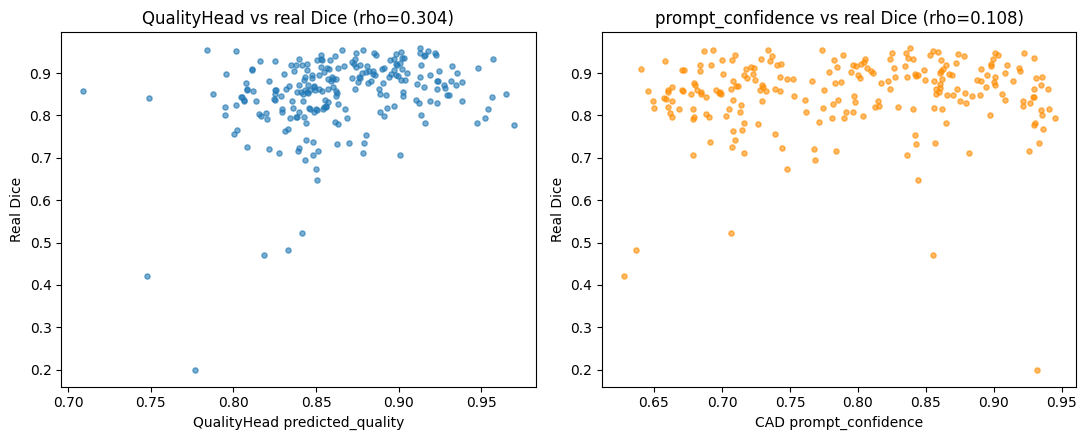

Saved CSV: results/integrated_center_mixed_sizetversky_qhead.csv


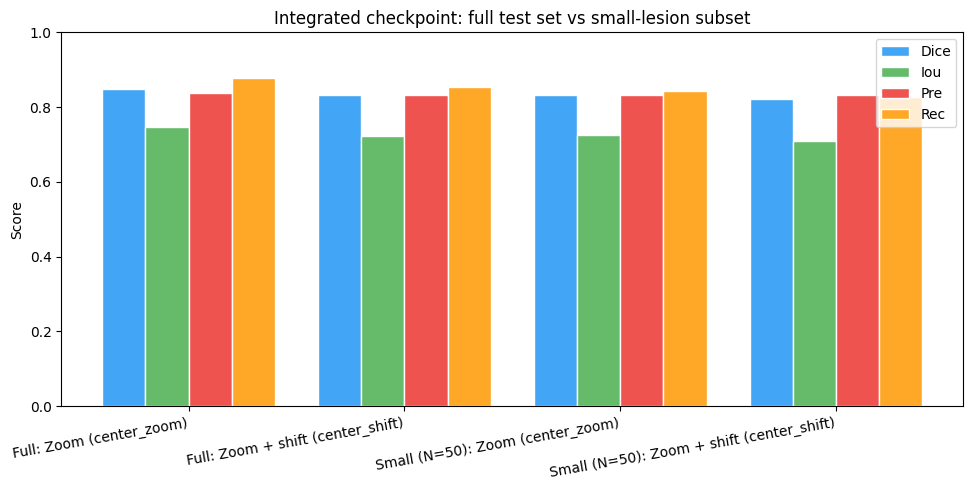

In [3]:
# @title
"""
test_integrated_center_mixed_sizetversky_qhead.py
=====================
Tests the integrated checkpoint (center_mixed x2/shift0.3, size-conditioned
Tversky, QualityHead, trained in the cell above) on:
1. The usual Zoom / Zoom + shift segmentation scenarios over the full test
   set, per-polygon samples.
2. The 50 test images with the smallest unioned GT area, grouped per source
   image exactly like Results/*/test-subcat-pga-vs-sam-r256-r512/, scored
   under both scenarios.
3. Whether QualityHead's predicted_quality and the free CAD
   prompt_confidence gate correlate with real per-sample Dice (Spearman),
   under the Zoom scenario.

Usage:
    python test_integrated_center_mixed_sizetversky_qhead.py
"""

import os
import sys
import cv2
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from scipy.ndimage import binary_erosion, distance_transform_edt
from scipy.stats import spearmanr

import importlib as _importlib
if 'dataset' in sys.modules: del sys.modules['dataset']
_importlib.invalidate_caches()
from dataset import PromptSegmentationDataset
from models.networks.prompt_unet_2D import PGA_UNet

# =========================================================
# CONFIGURATION - edit here
# =========================================================
DEVICE             = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH         = "checkpoints/pga_unet_center_mixed_x2_shift03_qhead_sizetversky_512_best.pth"
IMG_SIZE           = 512
BATCH_SIZE         = 4
USE_ENCODER_PROMPT = True   # must match the training config above

SCALE_FACTOR   = 2.0
SHIFT_RATIO    = 0.3
SMALL_SUBSET_N = 50

TEST_IMAGE_DIR = "dataset_BTXRD/test/images"
TEST_JSON_DIR  = "dataset_BTXRD/test/annotations"

METRIC_KEYS = ('dice', 'iou', 'pre', 'rec', 'hd95', 'cbl')


# =========================================================
# METRIC HELPERS & POST-PROCESSING
# =========================================================

def extract_lcc(binary_map: np.ndarray) -> np.ndarray:
    if binary_map.sum() == 0:
        return binary_map
    mask_uint8 = binary_map.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1:
        return binary_map
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest_label).astype(np.float32)

def calc_hd95(pred: np.ndarray, gt: np.ndarray) -> float:
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any():
        return 0.0
    if not pred.any() or not gt.any():
        return float(IMG_SIZE)
    pe = pred ^ binary_erosion(pred)
    ge = gt   ^ binary_erosion(gt)
    d1 = distance_transform_edt(~ge)[pe]
    d2 = distance_transform_edt(~pe)[ge]
    if not len(d1) or not len(d2):
        return float(IMG_SIZE)
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))

def calc_cbl(pred_bin: np.ndarray, gt_bin: np.ndarray):
    if gt_bin.sum() == 0:
        return None
    ys, xs = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max() - ys.min()) ** 2 +
                      (xs.max() - xs.min()) ** 2) + 1e-6
    if pred_bin.sum() == 0:
        return 0.0
    yp, xp = np.where(pred_bin)
    d = np.sqrt((xp.mean() - xs.mean()) ** 2 +
                (yp.mean() - ys.mean()) ** 2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))

def calc_metrics_img(prob: np.ndarray, gt: np.ndarray, smooth: float = 1e-6) -> dict:
    """Image-level metric, no per-polygon largest-connected-component
    filtering: a correct union of several polygon predictions for the same
    image can legitimately have more than one component. Matches
    calc_metrics_img in Results/*/test-subcat-pga-vs-sam-r256-r512/.
    """
    pm = (prob > 0.5).astype(np.float32)
    gm = (gt > 0.5).astype(np.float32)
    tp = (pm * gm).sum()
    fp = (pm * (1 - gm)).sum()
    fn = ((1 - pm) * gm).sum()
    cbl = calc_cbl(pm.astype(bool), gm.astype(bool))
    return dict(
        dice=float((2 * tp + smooth) / (2 * tp + fp + fn + smooth)),
        iou=float((tp + smooth) / (tp + fp + fn + smooth)),
        pre=float(tp / (tp + fp)) if (tp + fp) > 0 else 0.0,
        rec=float((tp + smooth) / (tp + fn + smooth)),
        hd95=calc_hd95(pm.astype(bool), gm.astype(bool)),
        cbl=cbl if cbl is not None else 0.0,
        area=float(gm.sum()),
    )


# =========================================================
# PER-SAMPLE EVALUATION (full test set)
# =========================================================

def run_eval_collect(model: torch.nn.Module, prompt_mode: str, **ds_kwargs) -> list:
    ds = PromptSegmentationDataset(
        image_dir=TEST_IMAGE_DIR,
        json_dir=TEST_JSON_DIR,
        img_size=IMG_SIZE,
        is_train=False,
        prompt_mode=prompt_mode,
        **ds_kwargs,
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    smooth = 1e-5
    samples = []

    model.eval()
    with torch.no_grad():
        for images, masks, prompts in loader:
            images  = images.to(DEVICE)
            masks   = masks.to(DEVICE)
            prompts = prompts.to(DEVICE)
            preds   = (torch.sigmoid(model(images, prompts)) > 0.5).float()

            for b in range(images.size(0)):
                pm = preds[b, 0].cpu().numpy()
                gm = masks[b, 0].cpu().numpy()
                pm = extract_lcc(pm)

                tp = (pm * gm).sum()
                fp = (pm * (1 - gm)).sum()
                fn = ((1 - pm) * gm).sum()
                cbl = calc_cbl(pm.astype(bool), gm.astype(bool))

                samples.append(dict(
                    dice=(2 * tp + smooth) / (2 * tp + fp + fn + smooth),
                    iou=(tp + smooth) / (tp + fp + fn + smooth),
                    pre=(tp + smooth) / (tp + fp + smooth),
                    rec=(tp + smooth) / (tp + fn + smooth),
                    hd95=calc_hd95(pm.astype(bool), gm.astype(bool)),
                    cbl=cbl if cbl is not None else 0.0,
                    area=float(gm.sum()),
                ))

    return samples


# =========================================================
# PER-STEM (PER SOURCE IMAGE) EVALUATION, matches
# Results/*/test-subcat-pga-vs-sam-r256-r512/
# =========================================================

def run_eval_stems(model: torch.nn.Module, ds: PromptSegmentationDataset) -> tuple:
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    stems = [name for name, _ in ds.all_samples]  # aligned with loader order (shuffle=False)

    stem_gt, stem_prob = {}, {}
    idx = 0
    model.eval()
    with torch.no_grad():
        for images, masks, prompts in loader:
            images  = images.to(DEVICE)
            masks   = masks.to(DEVICE)
            prompts = prompts.to(DEVICE)
            probs   = torch.sigmoid(model(images, prompts))

            for b in range(images.size(0)):
                stem = stems[idx]; idx += 1
                gm = masks[b, 0].cpu().numpy()
                pm = probs[b, 0].cpu().numpy()
                if stem not in stem_gt:
                    stem_gt[stem]   = gm.copy()
                    stem_prob[stem] = pm.copy()
                else:
                    stem_gt[stem]   = np.maximum(stem_gt[stem], gm)
                    stem_prob[stem] = np.maximum(stem_prob[stem], pm)

    return stem_gt, stem_prob


# =========================================================
# CONFIDENCE-SIGNAL VALIDATION: does predicted_quality / prompt_confidence
# actually track real per-sample Dice? Uses GT only to compute the real
# Dice for this check; the signals themselves need no GT to compute.
# =========================================================

def evaluate_confidence_signals(model: torch.nn.Module, prompt_mode: str, **ds_kwargs) -> dict:
    ds = PromptSegmentationDataset(
        image_dir=TEST_IMAGE_DIR, json_dir=TEST_JSON_DIR, img_size=IMG_SIZE,
        is_train=False, prompt_mode=prompt_mode, **ds_kwargs,
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    smooth = 1e-5
    real_dice, pred_quality, prompt_conf = [], [], []

    model.eval()
    with torch.no_grad():
        for images, masks, prompts in loader:
            images, masks, prompts = images.to(DEVICE), masks.to(DEVICE), prompts.to(DEVICE)
            logits, p_conf, p_quality = model(
                images, prompts, return_confidence=True, return_quality=True)
            preds = (torch.sigmoid(logits) > 0.5).float()

            for b in range(images.size(0)):
                pm = extract_lcc(preds[b, 0].cpu().numpy())
                gm = masks[b, 0].cpu().numpy()
                tp = (pm * gm).sum()
                fp = (pm * (1 - gm)).sum()
                fn = ((1 - pm) * gm).sum()
                real_dice.append((2 * tp + smooth) / (2 * tp + fp + fn + smooth))
                pred_quality.append(p_quality[b].item())
                prompt_conf.append(p_conf[b].item())

    real_dice, pred_quality, prompt_conf = map(np.array, (real_dice, pred_quality, prompt_conf))
    rho_quality, p_quality_val = spearmanr(pred_quality, real_dice)
    rho_prompt,  p_prompt_val  = spearmanr(prompt_conf, real_dice)

    print(f"\n{'=' * 72}\n  CONFIDENCE-SIGNAL VALIDATION  |  {prompt_mode}  |  N={len(real_dice)}\n{'=' * 72}")
    print(f"  QualityHead predicted_quality vs real Dice: Spearman rho={rho_quality:.4f} (p={p_quality_val:.4g})")
    print(f"  CAD prompt_confidence vs real Dice:          Spearman rho={rho_prompt:.4f} (p={p_prompt_val:.4g})")
    print("  rho close to 0 or negative means the signal does NOT track real quality; do not rely on it.")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].scatter(pred_quality, real_dice, s=14, alpha=0.6)
    axes[0].set_xlabel("QualityHead predicted_quality"); axes[0].set_ylabel("Real Dice")
    axes[0].set_title(f"QualityHead vs real Dice (rho={rho_quality:.3f})")
    axes[1].scatter(prompt_conf, real_dice, s=14, alpha=0.6, color="darkorange")
    axes[1].set_xlabel("CAD prompt_confidence"); axes[1].set_ylabel("Real Dice")
    axes[1].set_title(f"prompt_confidence vs real Dice (rho={rho_prompt:.3f})")
    plt.tight_layout()
    plt.show()

    return dict(rho_quality=rho_quality, rho_prompt=rho_prompt)


def aggregate(samples: list) -> dict:
    out = {k: float(np.mean([s[k] for s in samples])) for k in METRIC_KEYS}
    out['n'] = len(samples)
    return out

def print_metrics(title: str, m: dict):
    print(f"\n{'=' * 90}\n  {title}\n{'=' * 90}")
    print(f"  Dice={m['dice']:.4f}  IoU={m['iou']:.4f}  Pre={m['pre']:.4f}"
          f"  Rec={m['rec']:.4f}  HD95={m['hd95']:.2f}  CBL={m['cbl']:.4f}  N={m['n']}")


# =========================================================
# LOAD MODEL
# =========================================================
model = PGA_UNet(use_encoder_prompt=USE_ENCODER_PROMPT, use_quality_head=True).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f"Model loaded from: {MODEL_PATH}")

# =========================================================
# 1) FULL TEST SET
# =========================================================
scenarios = {
    'Zoom (center_zoom)':          dict(prompt_mode='center_zoom', scale_factor=SCALE_FACTOR),
    'Zoom + shift (center_shift)': dict(prompt_mode='center_shift', scale_factor=SCALE_FACTOR, shift_ratio=SHIFT_RATIO),
}

full_metrics = {}
for scenario_name, kwargs in scenarios.items():
    m = aggregate(run_eval_collect(model, **kwargs))
    full_metrics[scenario_name] = m
    print_metrics(f"FULL TEST SET  |  {scenario_name}", m)

# =========================================================
# 2) SMALL-LESION SUBSET (50 images, smallest GT area), both scenarios
# =========================================================
ds_by_scenario = {
    scenario_name: PromptSegmentationDataset(
        image_dir=TEST_IMAGE_DIR, json_dir=TEST_JSON_DIR, img_size=IMG_SIZE,
        is_train=False, **kwargs,
    )
    for scenario_name, kwargs in scenarios.items()
}
stem_results = {name: run_eval_stems(model, ds) for name, ds in ds_by_scenario.items()}

stem_gt_zoom = stem_results['Zoom (center_zoom)'][0]
small_stems = sorted(stem_gt_zoom.keys(), key=lambda st: stem_gt_zoom[st].sum())[:SMALL_SUBSET_N]
print(f"\nSmall-lesion subset: {len(small_stems)} images, "
      f"area {stem_gt_zoom[small_stems[0]].sum():.0f} -> {stem_gt_zoom[small_stems[-1]].sum():.0f} px")

small_metrics = {}
for scenario_name, (stem_gt, stem_prob) in stem_results.items():
    m = aggregate([calc_metrics_img(stem_prob[st], stem_gt[st]) for st in small_stems])
    small_metrics[scenario_name] = m
    print_metrics(f"SMALL-LESION SUBSET (N={SMALL_SUBSET_N} images, smallest GT area)  |  {scenario_name}", m)

# =========================================================
# 3) CONFIDENCE-SIGNAL VALIDATION (Zoom condition, the primary one)
# =========================================================
confidence_results = evaluate_confidence_signals(
    model, prompt_mode='center_zoom', scale_factor=SCALE_FACTOR)

# =========================================================
# SAVE CSV
# =========================================================
os.makedirs('results', exist_ok=True)
with open('results/integrated_center_mixed_sizetversky_qhead.csv', 'w', newline='', encoding='utf-8') as f:
    f.write('group,scenario,' + ','.join(METRIC_KEYS) + ',n\n')
    for scenario_name, m in full_metrics.items():
        f.write(f"Full test set,{scenario_name}," + ','.join(f"{m[k]:.4f}" for k in METRIC_KEYS) + f",{m['n']}\n")
    for scenario_name, m in small_metrics.items():
        f.write(f"Small-lesion subset,{scenario_name}," + ','.join(f"{m[k]:.4f}" for k in METRIC_KEYS) + f",{m['n']}\n")
print("Saved CSV: results/integrated_center_mixed_sizetversky_qhead.csv")

# =========================================================
# BAR CHART - Dice/IoU/Pre/Rec across all four groups
# =========================================================
groups, group_metrics = [], []
for scenario_name, m in full_metrics.items():
    groups.append(f'Full: {scenario_name}')
    group_metrics.append(m)
for scenario_name, m in small_metrics.items():
    groups.append(f'Small (N={SMALL_SUBSET_N}): {scenario_name}')
    group_metrics.append(m)

x = np.arange(len(groups)); w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
for i, (key, color) in enumerate(zip(('dice', 'iou', 'pre', 'rec'),
                                     ('#42a5f5', '#66bb6a', '#ef5350', '#ffa726'))):
    vals = [m[key] for m in group_metrics]
    ax.bar(x + (i - 1.5) * w, vals, w, label=key.capitalize(), color=color, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(groups, rotation=10, ha='right')
ax.set_ylim(0, 1); ax.set_ylabel('Score')
ax.set_title('Integrated checkpoint: full test set vs small-lesion subset')
ax.legend()
plt.tight_layout()
plt.show()
